In [1]:
import tensorflow as tf
# coloca uma seed para reproduzir o mesmos dados da aula
tf.random.set_seed(1)

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [2]:
from tensorflow.keras.datasets import fashion_mnist

#carregando a base do MNIST
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
import numpy as np

#juntando os dados de treino e teste
dataset = np.concatenate([x_train, x_test], axis=0)
# colocando os dados em padrao 0-1, normalização
dataset = np.expand_dims(dataset, -1).astype("float32") / 255

In [4]:
BATCH_SIZE = 64

# colocando nas dimensoes adequadas para o uso nas camadas concolucionais
dataset = np.reshape(dataset, (-1, 28, 28, 1))

# criando um tensor ccom a base
dataset = tf.data.Dataset.from_tensor_slices(dataset)

# embaralhando os dados e colcoando em lotes de 64
dataset = dataset.shuffle(buffer_size=1024).batch(BATCH_SIZE)

In [6]:
from tensorflow import keras
from tensorflow.keras import layers

# hiperparametro que diz a quantidade de ruido de entrada
NOISE_DIM = 150

generator = keras.models.Sequential([
  keras.layers.InputLayer(input_shape=(NOISE_DIM,)),# camada de entrada com a quantidade de ruidos
  layers.Dense(7*7*256),# camada densa com 12544 neuronios
  layers.Reshape(target_shape=(7, 7, 256)),# mudando o tamanho para 7x7 e 256 canais(3d), que antes era um vetor 1D
  layers.Conv2DTranspose(256, 3, strides=2, padding="same"),# camada transposta aumenta o tamnho da imagem, ao inves de iminuir igual ao conv2d
  layers.LeakyReLU(),
  layers.Conv2DTranspose(128, 3, strides=2, padding="same"),
  layers.LeakyReLU(),
  layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")# saida com 1 canal, com um kernel de 3x3 garante que os dados sejam normalizados para 0-1 como foi feito anteriormente
])

generator.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 12544)          │     1,894,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 256)    │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 28, 28, 1)      │         1,153 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,780,417 (10.61 MB)

 Trainable params: 2,780,417 (10.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# o descriminador vai diminuir as imagens e identificar as caracteristicas para assim compara com a original
discriminator = keras.models.Sequential([
  keras.layers.InputLayer(input_shape=(28, 28, 1)),# camada de entrada
  layers.Conv2D(256, 3, activation="relu", strides=2, padding="same"),# conv com 256 filtros
  layers.Conv2D(128, 3, activation="relu", strides=2, padding="same"),
  layers.Flatten(),# achata para vetor
  layers.Dense(64, activation="relu"),
  layers.Dropout(0.2),# reduz o overfitting
  layers.Dense(1, activation="sigmoid")# saida 0-1
])

discriminator.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 256)    │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       401,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 699,137 (2.67 MB)

 Trainable params: 699,137 (2.67 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
optimizerG = keras.optimizers.Adam(learning_rate=0.00001, beta_1=0.5)
#otimizador do gerador, o lr rate baixo ajuda a manter o treino estavel
optimizerD = keras.optimizers.Adam(learning_rate=0.00003, beta_1=0.5)
#otimizador do descriminador

#loss = classificador binario para o descriminador
lossFn = keras.losses.BinaryCrossentropy(from_logits=True)

# auracia do gerador e do descriminador
gAccMetric = tf.keras.metrics.BinaryAccuracy() # com o classificador mede o quao bem consegue enganar o descriminador
dAccMetric = tf.keras.metrics.BinaryAccuracy()# mede o quanto consegue identificar as imagens reais e as fakes

In [9]:
@tf.function
def trainDStep(data):
  batchSize = tf.shape(data)[0]
  # pega o tamanho do batc com bse em sua primeira dimensao

  # criando um ruido com base no batch(distribuição normal)
  noise = tf.random.normal(shape=(batchSize, NOISE_DIM))

  #criando dois vetores para rotular a imagem original e a falsa
  y_true = tf.concat(
    [
      tf.ones(batchSize, 1),# 1 para real
      tf.zeros(batchSize, 1)#0 para falso
    ],
    axis=0
  )

  with tf.GradientTape() as tape:

    # geramos uma imagem fake através do gerador
    fake = generator(noise)

    #juntando os dados reais e os falsos
    x = tf.concat([data, fake], axis=0)

    #pegando a previsao do descriminador, onde ele vai compara a imagem real e a fake assim para tentar descobrir qual é qual
    y_pred = discriminator(x)
    # #calculando o loss pelo real contra o previsto
    discriminatorLoss = lossFn(y_true, y_pred)

  # pegga o loss e os pesos do descriminador para atualizar o gradiente
  grads = tape.gradient(discriminatorLoss, discriminator.trainable_weights)

  # aplica a otimização dos pesos a parti do calculo do gradiente
  optimizerD.apply_gradients(zip(grads, discriminator.trainable_weights))

  #calculando a acuracia com base no real e no previsto
  dAccMetric.update_state(y_true, y_pred)

  # # retorna o loss e a acuracia do descriminador
  return {
      "discriminator_loss": discriminatorLoss,
      "discriminator_accuracy": dAccMetric.result()
  }

In [10]:
@tf.function
def trainGStep(data):
  batchSize = tf.shape(data)[0]
  #batch para o gerador
  noise = tf.random.normal(shape=(batchSize, NOISE_DIM))
  #distribuição normal(ruido)

  # gerando rotulos reais, para que seja usado posteriormente o descriminador treinado para assim apontar o quanto o gerador esta longe de enganar o descriminador
  y_true = tf.ones(batchSize, 1)

  with tf.GradientTape() as tape:
    y_pred = discriminator(generator(noise))
    # gerando a imagem pelo gerador a partir do ruido(distribuição normal)
    generatorLoss = lossFn(y_true, y_pred)
    # calcula a funcao de perda do geraador

  # calculando o gradiente e aplicando as correções
  grads = tape.gradient(generatorLoss, generator.trainable_weights)
  optimizerG.apply_gradients(zip(grads, generator.trainable_weights))

  # mede a acuracia do gerador
  gAccMetric.update_state(y_true, y_pred)

  return {
      "generator_loss": generatorLoss,
      "generator_accuracy": gAccMetric.result()
  }

In [11]:
from matplotlib import pyplot as plt

# grid com 81 umagens criadas pelo gerador, passando ruidos como entrada
def plotImages(model):
    images = model(np.random.normal(size=(81, NOISE_DIM)))

    plt.figure(figsize=(9, 9))

    for i, image in enumerate(images):
        plt.subplot(9,9,i+1)
        plt.imshow(np.squeeze(image, -1), cmap="Greys_r")
        plt.axis('off')

    plt.show();

/usr/local/lib/python3.13/dist-packages/keras/src/backend/tensorflow/nn.py:1286: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


E:0, Loss G:2.7997, Loss D:0.1225, Acc G:%0.23, Acc D:%96.78


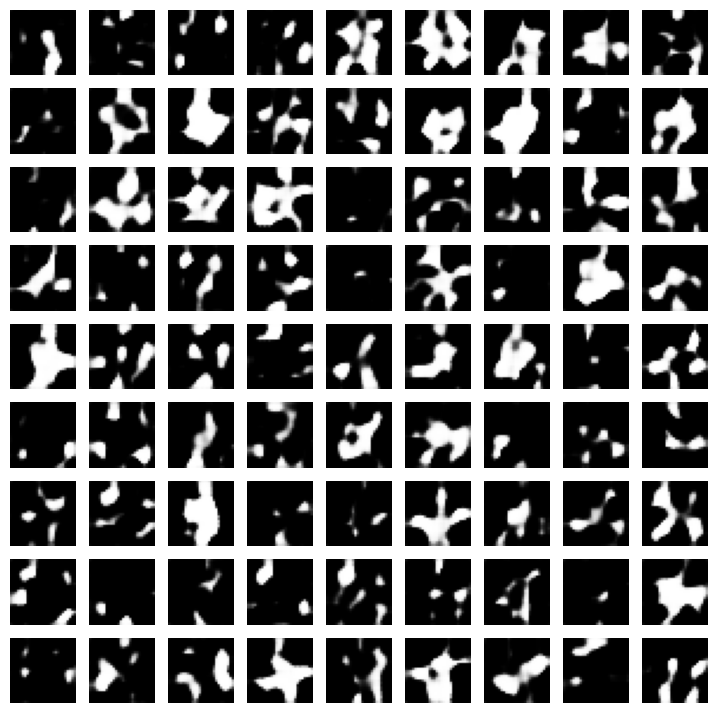

E:1, Loss G:3.1649, Loss D:0.1147, Acc G:%0.56, Acc D:%97.95
E:2, Loss G:2.6168, Loss D:0.1671, Acc G:%1.09, Acc D:%97.04


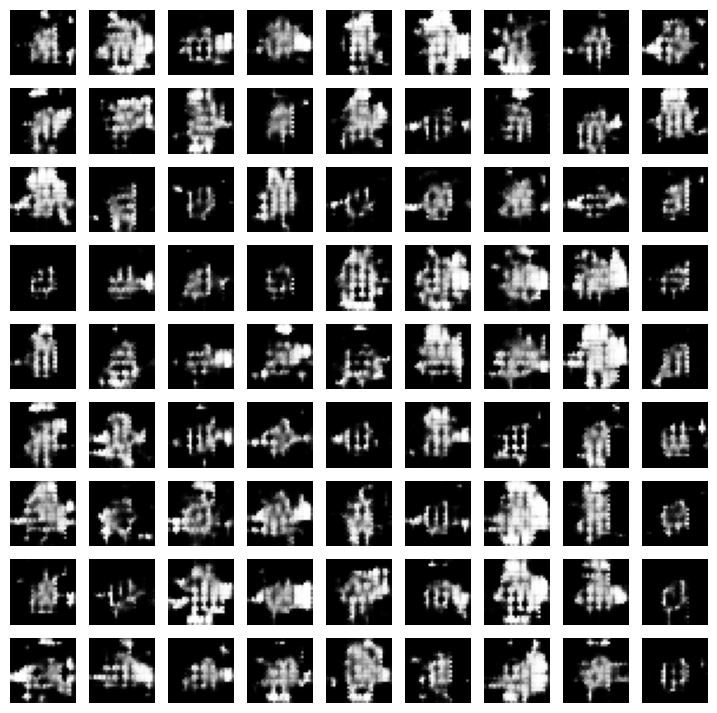

E:3, Loss G:2.4466, Loss D:0.1892, Acc G:%1.40, Acc D:%96.31
E:4, Loss G:2.1641, Loss D:0.2444, Acc G:%2.00, Acc D:%95.31


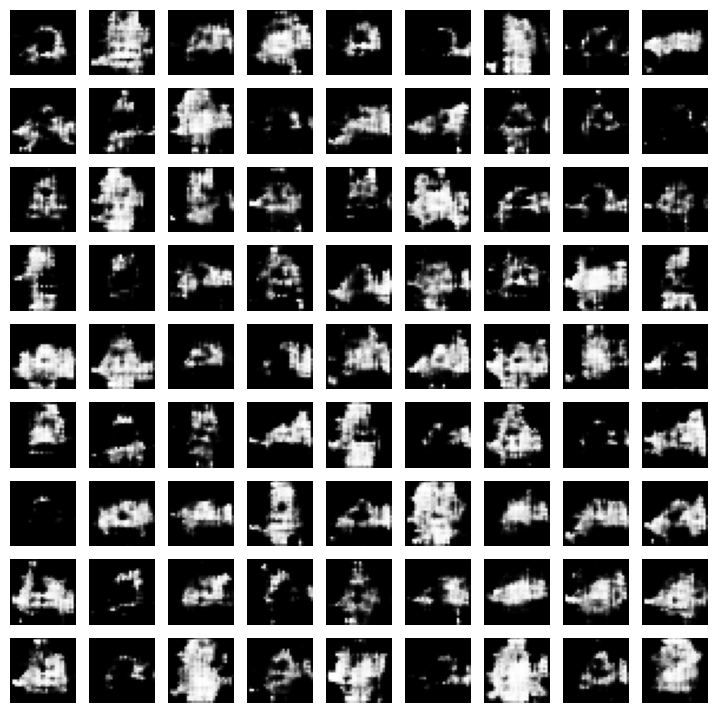

E:5, Loss G:2.0943, Loss D:0.2804, Acc G:%2.73, Acc D:%94.36
E:6, Loss G:2.0577, Loss D:0.2637, Acc G:%3.13, Acc D:%93.80


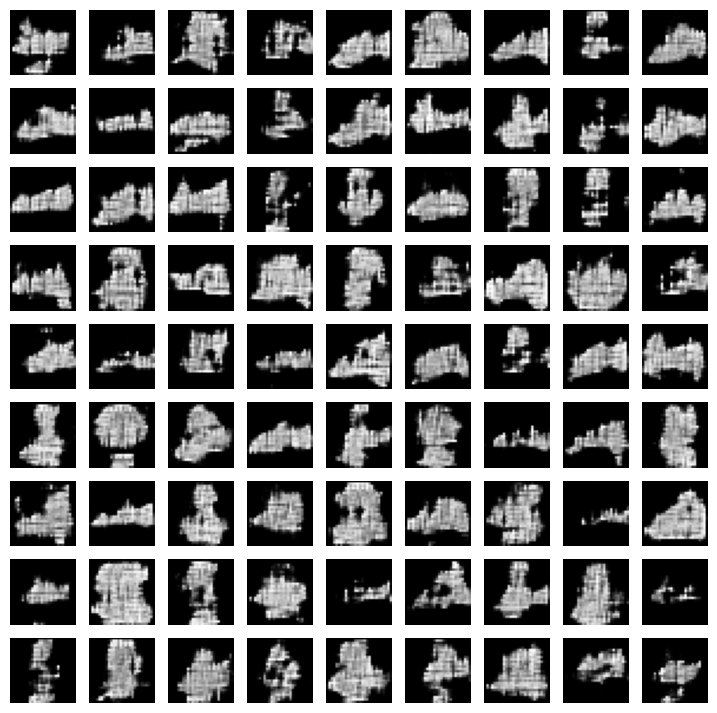

E:7, Loss G:1.8618, Loss D:0.3101, Acc G:%3.47, Acc D:%93.23
E:8, Loss G:1.7174, Loss D:0.3416, Acc G:%4.01, Acc D:%92.46


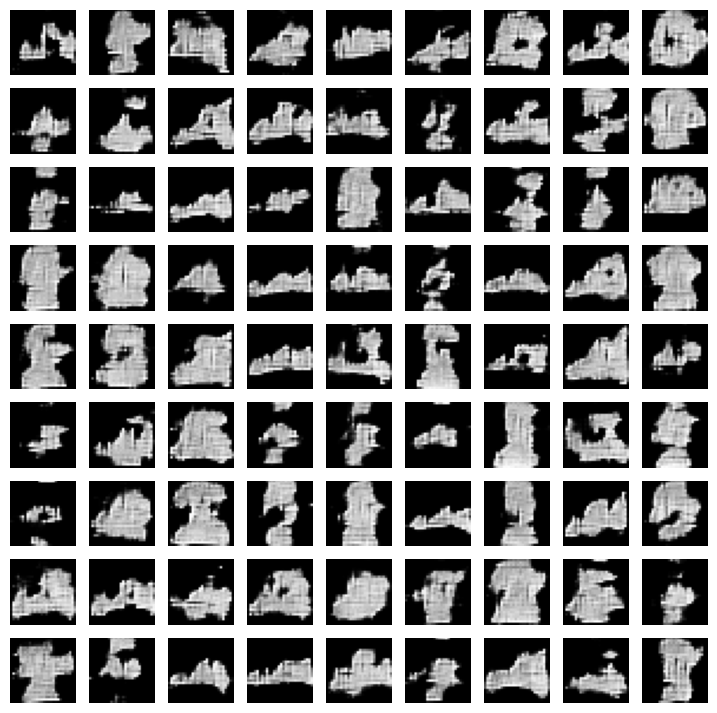

E:9, Loss G:1.7677, Loss D:0.3030, Acc G:%4.32, Acc D:%92.00
E:10, Loss G:1.8300, Loss D:0.2978, Acc G:%4.48, Acc D:%91.70


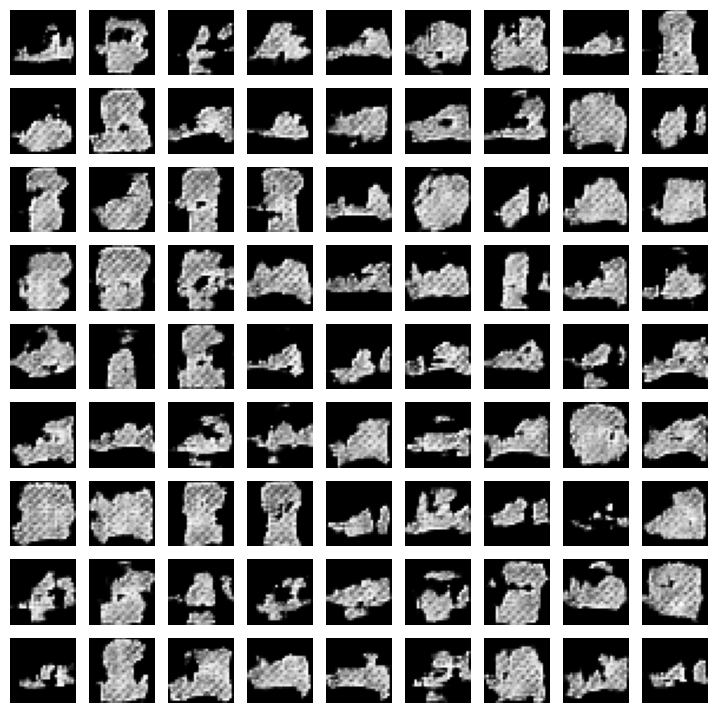

E:11, Loss G:1.9994, Loss D:0.2730, Acc G:%4.59, Acc D:%91.51
E:12, Loss G:2.0980, Loss D:0.2553, Acc G:%4.61, Acc D:%91.44


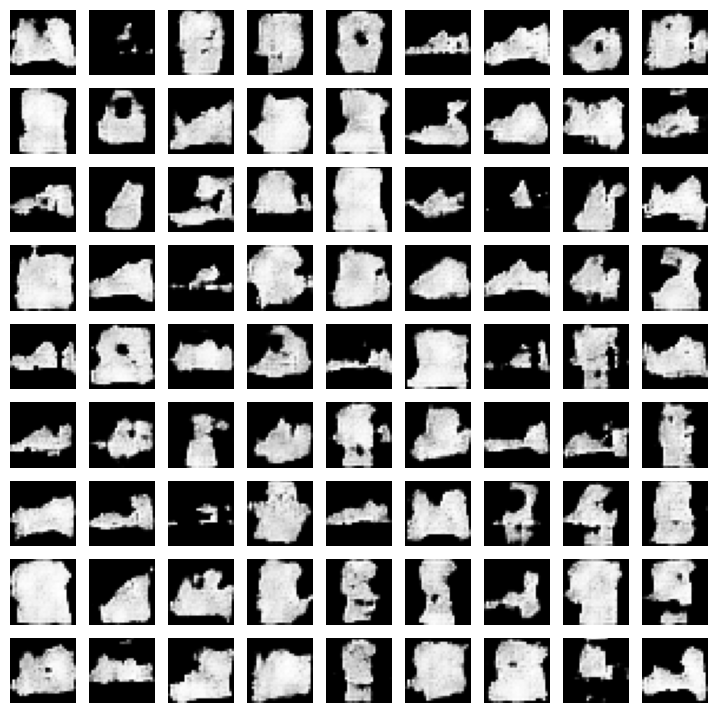

E:13, Loss G:2.1482, Loss D:0.2448, Acc G:%4.62, Acc D:%91.41
E:14, Loss G:2.2138, Loss D:0.2392, Acc G:%4.62, Acc D:%91.39


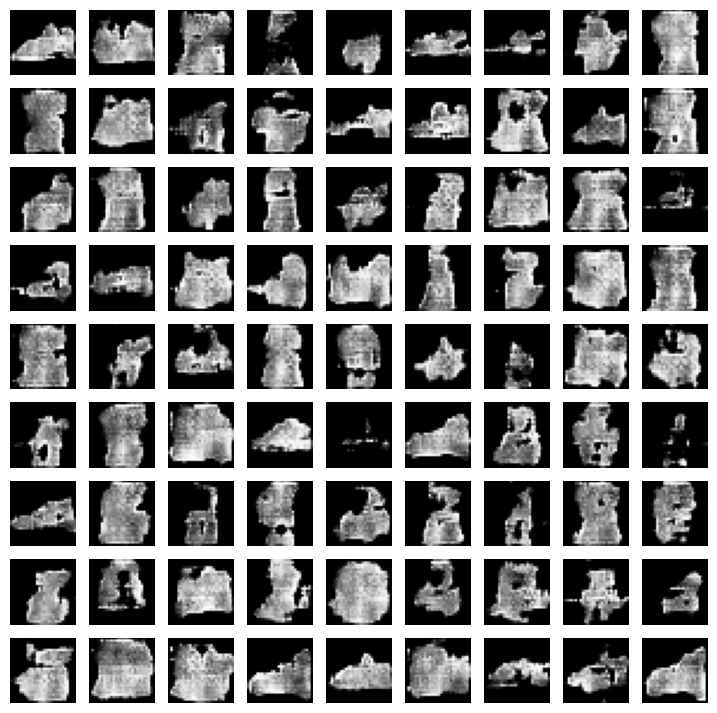

E:15, Loss G:2.1944, Loss D:0.2544, Acc G:%4.62, Acc D:%91.38
E:16, Loss G:2.1965, Loss D:0.2621, Acc G:%4.69, Acc D:%91.32


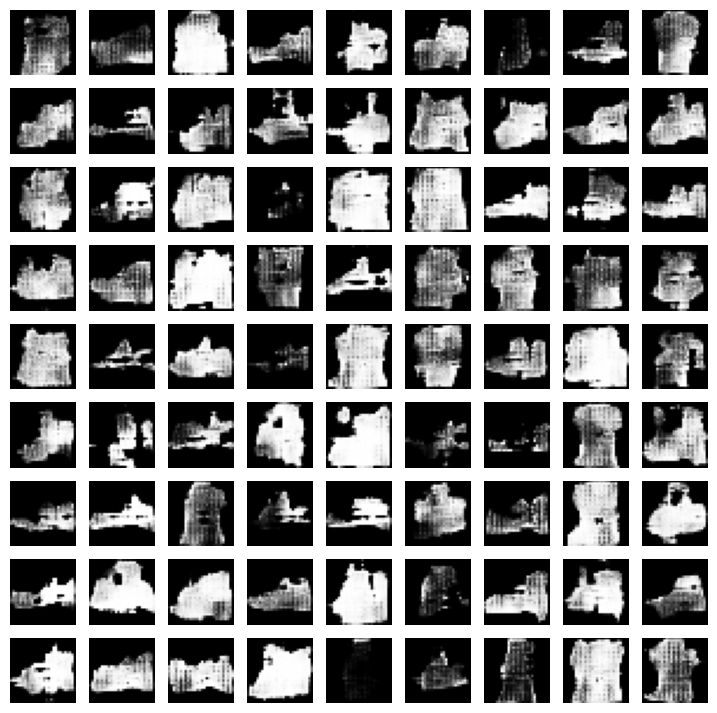

E:17, Loss G:2.1261, Loss D:0.2670, Acc G:%4.76, Acc D:%91.25
E:18, Loss G:2.0928, Loss D:0.2661, Acc G:%4.82, Acc D:%91.19


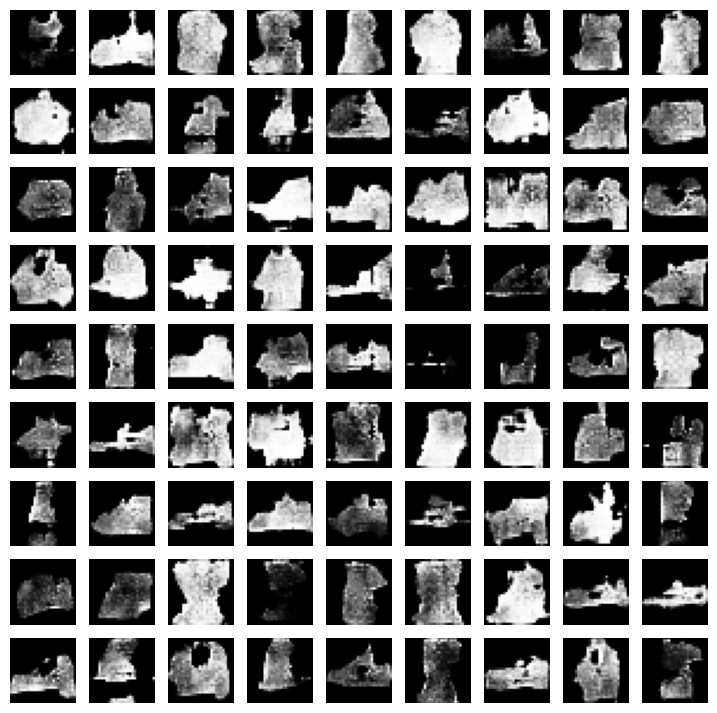

E:19, Loss G:2.0803, Loss D:0.2693, Acc G:%4.88, Acc D:%91.12
E:20, Loss G:2.0800, Loss D:0.2667, Acc G:%4.93, Acc D:%91.06


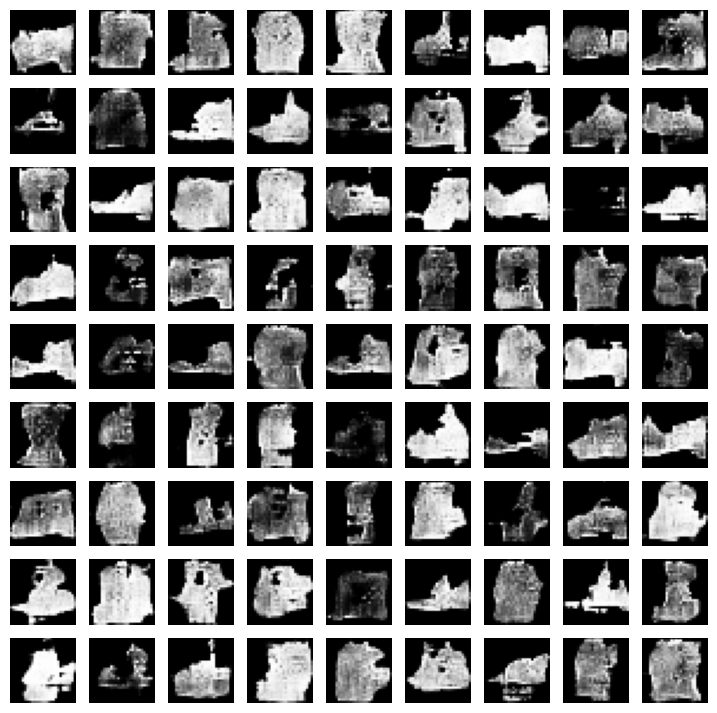

E:21, Loss G:2.0718, Loss D:0.2644, Acc G:%4.96, Acc D:%91.02
E:22, Loss G:2.0758, Loss D:0.2669, Acc G:%4.98, Acc D:%90.99


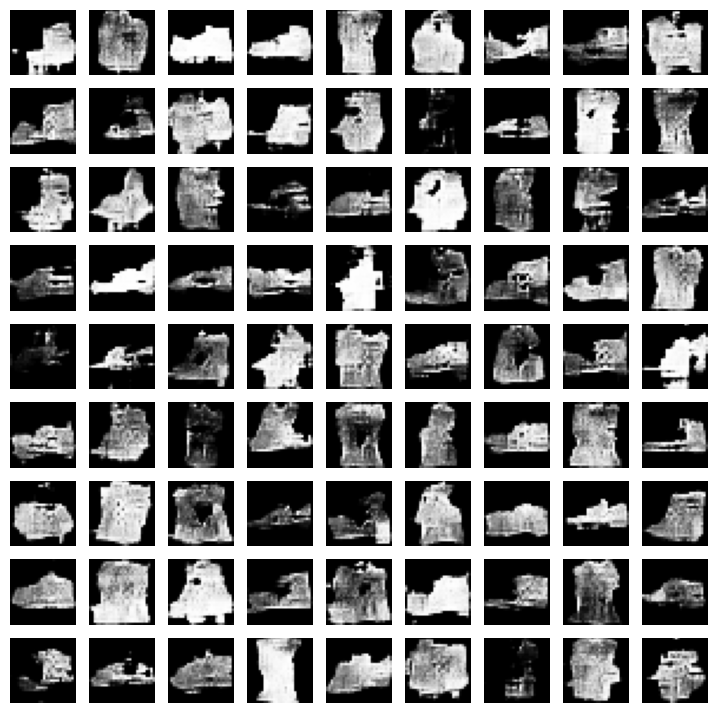

E:23, Loss G:2.0853, Loss D:0.2641, Acc G:%5.02, Acc D:%90.94
E:24, Loss G:2.0853, Loss D:0.2654, Acc G:%5.04, Acc D:%90.91


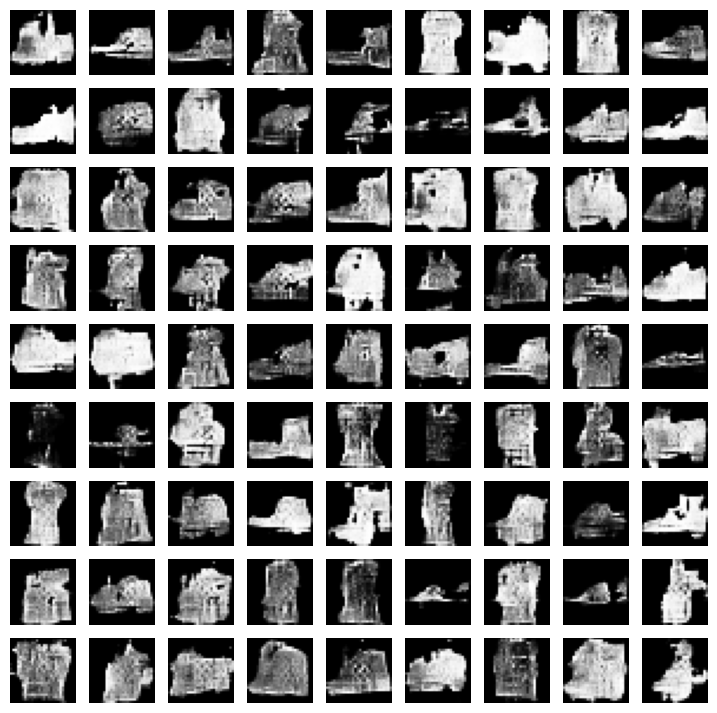

E:25, Loss G:2.0793, Loss D:0.2674, Acc G:%5.06, Acc D:%90.88
E:26, Loss G:2.0621, Loss D:0.2710, Acc G:%5.08, Acc D:%90.84


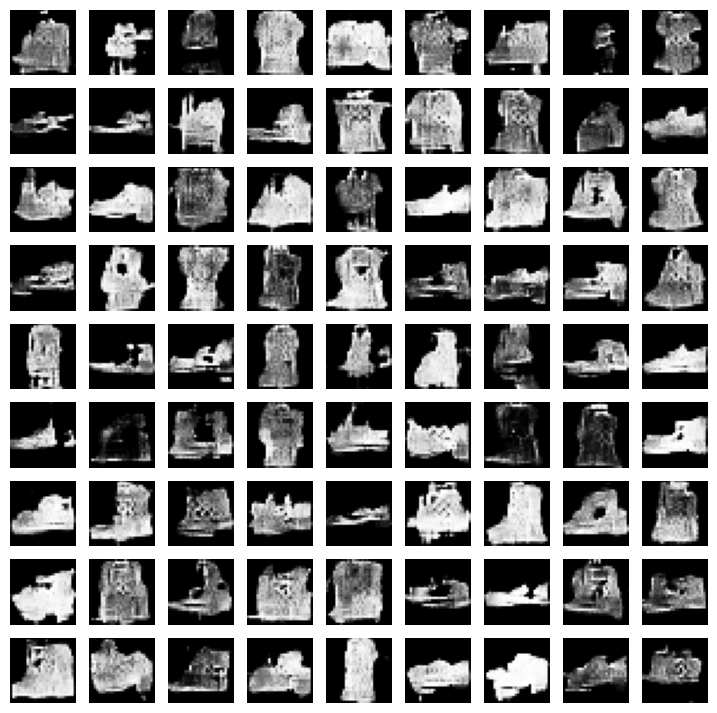

E:27, Loss G:2.0678, Loss D:0.2744, Acc G:%5.11, Acc D:%90.80
E:28, Loss G:2.0654, Loss D:0.2729, Acc G:%5.14, Acc D:%90.75


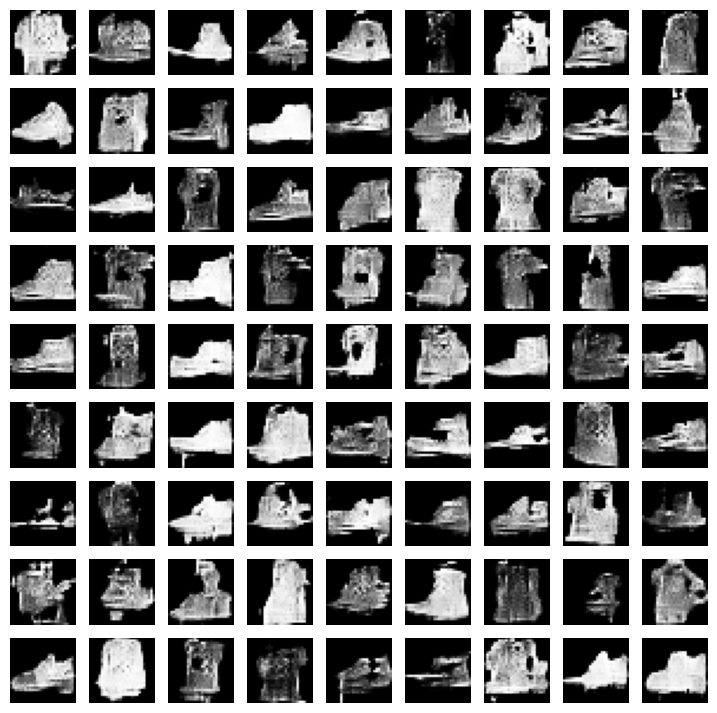

E:29, Loss G:2.0681, Loss D:0.2719, Acc G:%5.17, Acc D:%90.71


In [12]:
# treinamento do GAN
for epoch in range(30):

  # zerada as funcoes de perda e acuracia para gera a media ao fim da epoch
  dLossSum = 0
  gLossSum = 0
  dAccSum = 0
  gAccSum = 0
  cnt = 0

  for batch in dataset:

    #para cada batch treina o descriminador e adiciona o loss e a acuracia
    dLoss = trainDStep(batch)
    dLossSum += dLoss['discriminator_loss']
    dAccSum += dLoss['discriminator_accuracy']

    # treinando o gerador
    gLoss = trainGStep(batch)
    gLossSum += gLoss['generator_loss']
    gAccSum += gLoss['generator_accuracy']

    # incrementando o counter
    cnt += 1

#vendo como foi o treino
  print("E:{}, Loss G:{:0.4f}, Loss D:{:0.4f}, Acc G:%{:0.2f}, Acc D:%{:0.2f}".format(
      epoch,
      gLossSum/cnt,
      dLossSum/cnt,
      100 * gAccSum/cnt,
      100 * dAccSum/cnt
  ))

  if epoch % 2 == 0:
    plotImages(generator)

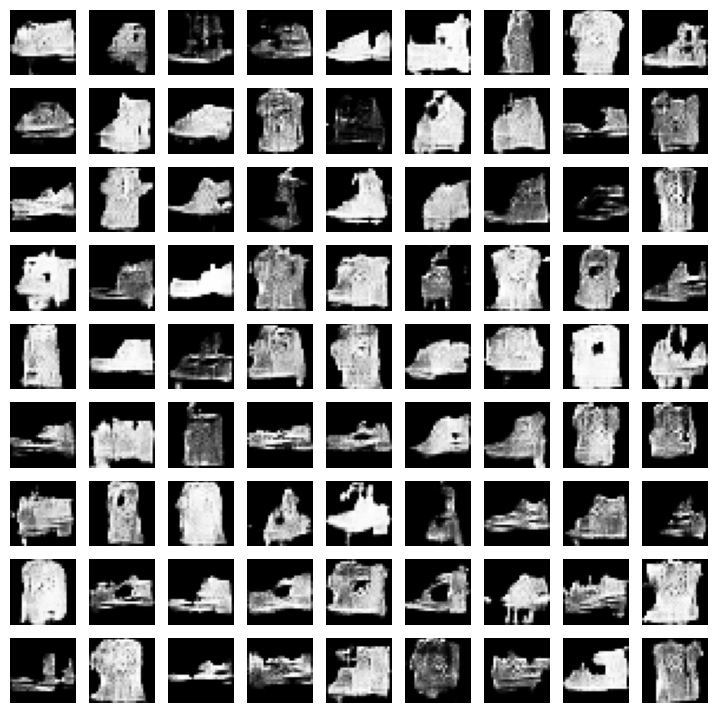

In [13]:
#gerando imagen para ver como foi o modelo ja treinado
images = generator(np.random.normal(size=(81, NOISE_DIM)))

from matplotlib import pyplot as plt

plt.figure(figsize=(9, 9))

for i, image in enumerate(images):
    plt.subplot(9,9,i+1)
    plt.imshow(np.squeeze(image, -1), cmap="Greys_r")
    plt.axis('off')

plt.show();